In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns  

df = pd.read_csv('fake_friends.csv')
df.head()

,datapointID,text
0,0,Cleric in Najaf Refuses to Meet Iraqi Mediator...
1,1,School #39;s out to shun IE Citing security ri...
2,2,How do I begin to review a film that will soon...
3,3,ANALYSIS-Suspected Islamist killing tests Dutc...
4,4,Venezuela Boosts Taxes on Orinoco Deals &lt;p&...


In [4]:
import torch
from transformers import AutoTokenizer, AutoModel
import os

model = AutoModel.from_pretrained("BAAI/bge-small-en-v1.5")
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-small-en-v1.5")

#This is all taken from the starter kit. Not the best way to handle embeddings, yet it worked perfectly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)
model.eval()

embeddings = []
with torch.no_grad():
    for text in df['text']:
        encoded_input = tokenizer(text, return_tensors='pt').to(device)
        model_output = model(**encoded_input)
        embeddings.append(model_output[0][:, 0].cpu().numpy())

embeddings= np.array(embeddings).reshape(7000, 384)

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

c:\Users\Teodor\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Teodor\.cache\huggingface\hub\models--BAAI--bge-small-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

cuda


# Subtask 1

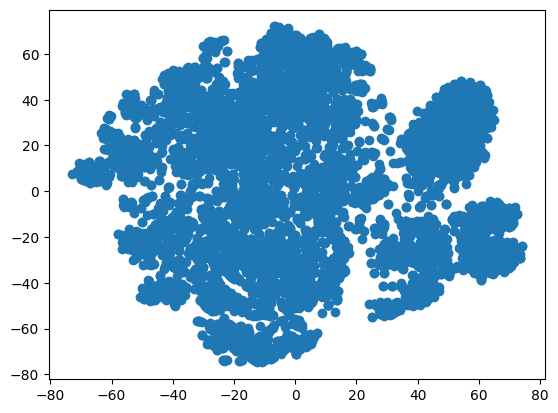

In [5]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

embeddings_reduced = TruncatedSVD(50, random_state=42).fit_transform(embeddings)  
xy = TSNE(2, random_state=42).fit_transform(embeddings_reduced)

plt.scatter(x=xy[:, 0], y=xy[:, 1])
plt.show()

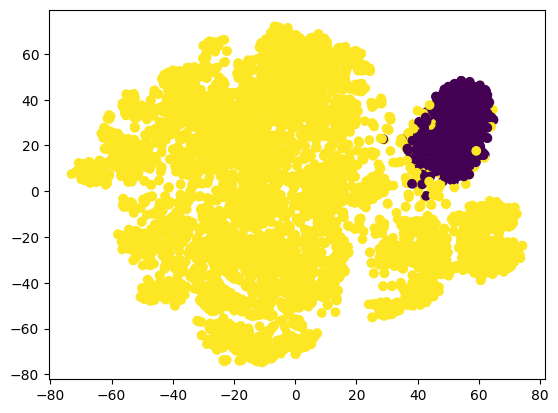

In [6]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(2, covariance_type='diag', n_init=30, random_state=42)
preds_s1 = gmm.fit_predict(embeddings_reduced)

plt.scatter(x=xy[:, 0], y=xy[:, 1], c=preds_s1)
plt.show()

# Subtask 2

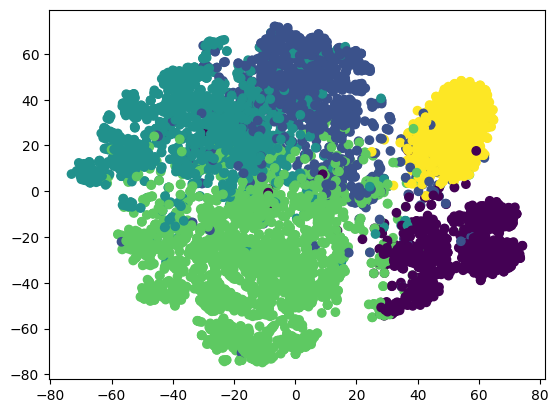

,is_noise,topic
0,0,3
1,0,1
2,1,4
3,0,3
4,0,2


In [7]:
gmm2 = GaussianMixture(5, covariance_type='diag', n_init=30, random_state=42) 
preds_s2 = gmm2.fit_predict(embeddings_reduced)

plt.scatter(x=xy[:, 0], y=xy[:, 1], c=preds_s2)
plt.show()

def inverse(x):
    if x == 1:
        return 0   
    else:    
        return 1

preds_s1_final = [inverse(x) for x in preds_s1]

temp_df = pd.DataFrame({
    'is_noise':preds_s1_final, 
    'topic':preds_s2
})

temp_df.head()

In [8]:
preds_s2_final = []

for i in temp_df.index: 
    row = temp_df.iloc[i]
    if row['is_noise'] == 1:
        preds_s2_final.append(-1)
    else:
        preds_s2_final.append(int(row['topic']))

temp_df['topic'] = preds_s2_final
temp_df.head()

,is_noise,topic
0,0,3
1,0,1
2,1,-1
3,0,3
4,0,2


In [9]:
output_df = pd.DataFrame({
    'subtaskID':[1] * len(df) + [2] * len(df), 
    'datapointID':list(df['datapointID']) * 2,
    'answer':preds_s1_final + preds_s2_final
})
output_df.to_csv('submission.csv', index=False)
output_df.head()

,subtaskID,datapointID,answer
0,1,0,0
1,1,1,0
2,1,2,1
3,1,3,0
4,1,4,0
